# 1차시 - 데이터 로드 및 전처리

In [1]:
# Colab에서 한글 폰트 설정을 위한 코드
!apt-get update -qq # apt 패키지 리스트 업데이트
!apt-get install -y fonts-nanum # 나눔 폰트 설치

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔바른고딕 폰트 경로
fm.fontManager.addfont(fontpath) # 폰트 매니저에 폰트 추가
plt.rcParams['font.family'] = 'NanumBarunGothic' # 기본 폰트 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("한글 폰트 'NanumBarunGothic'이(가) 설정되었습니다.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 9 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (7,511 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
한글 폰트 'NanumBarunGothic'이(가) 설정되었습

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/workspace/lecture/data/14W/NHIS_Medical_Bill_Details_2023.CSV', encoding='cp949')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13831382 entries, 0 to 13831381
Data columns (total 18 columns):
 #   Column      Dtype  
---  ------      -----  
 0   기준년도        int64  
 1   가입자일련번호     int64  
 2   진료내역일련번호    int64  
 3   성별코드        int64  
 4   연령대코드       int64  
 5   시도코드        int64  
 6   요양개시일자      object 
 7   서식코드        int64  
 8   진료과목코드      int64  
 9   주상병코드       object 
 10  부상병코드       object 
 11  요양일수        int64  
 12  입내원일수       int64  
 13  심결가산율       float64
 14  심결요양급여비용총액  int64  
 15  심결본인부담금     int64  
 16  심결보험자부담금    int64  
 17  총처방일수       int64  
dtypes: float64(1), int64(14), object(3)
memory usage: 1.9+ GB


In [5]:
# 사용할 컬럼 리스트
categorical_features = [
    '성별코드', '연령대코드', '시도코드', '서식코드', '진료과목코드', '주상병코드'
]

numeric_features = [
    '요양일수', '입내원일수', '총처방일수', '심결가산율', '심결요양급여비용총액', '심결본인부담금'
]

selected_columns = categorical_features + numeric_features
df = df[selected_columns].copy()

In [6]:
# 범주형 일괄 변환
for col in categorical_features:
  if col in df.columns:
    df[col] = df[col].astype('category')

print("선택된 컬럼들을 category 타입으로 변환 완료!")
print(df.info())

선택된 컬럼들을 category 타입으로 변환 완료!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13831382 entries, 0 to 13831381
Data columns (total 12 columns):
 #   Column      Dtype   
---  ------      -----   
 0   성별코드        category
 1   연령대코드       category
 2   시도코드        category
 3   서식코드        category
 4   진료과목코드      category
 5   주상병코드       category
 6   요양일수        int64   
 7   입내원일수       int64   
 8   총처방일수       int64   
 9   심결가산율       float64 
 10  심결요양급여비용총액  int64   
 11  심결본인부담금     int64   
dtypes: category(6), float64(1), int64(5)
memory usage: 725.8 MB
None


In [7]:
# 데이터 타입 최적화(메모리 절약)
# int64는 메모리를 많이 차지 int32나 int16으로 변환하면 메모리 절약
def optimize_types(df):
  for col in df.columns:
    if df[col].dtype == 'int64':
      df[col] = pd.to_numeric(df[col], downcast='integer')
    elif df[col].dtype == 'float64':
      df[col] = pd.to_numeric(df[col], downcast='float')
  return df

df = optimize_types(df)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13831382 entries, 0 to 13831381
Data columns (total 12 columns):
 #   Column      Dtype   
---  ------      -----   
 0   성별코드        category
 1   연령대코드       category
 2   시도코드        category
 3   서식코드        category
 4   진료과목코드      category
 5   주상병코드       category
 6   요양일수        int16   
 7   입내원일수       int16   
 8   총처방일수       int16   
 9   심결가산율       float32 
 10  심결요양급여비용총액  int32   
 11  심결본인부담금     int32   
dtypes: category(6), float32(1), int16(3), int32(2)
memory usage: 330.1 MB
None


In [8]:
# 샘플링
sample_size = int(len(df) * 0.1) # 10% 데이터만 사용
df_sample = df.sample(n=sample_size, random_state=42)
print(f"원본데이터: {len(df)} 건")
print(f"샘플데이터: {len(df_sample)} 건")

원본데이터: 13831382 건
샘플데이터: 1383138 건


## 파생변수 생성

In [9]:
df_sample['주상병코드'].head()

,주상병코드
9467921,H6530
12843035,G20
13067324,C679
1865957,E149
5403125,S9610


In [10]:
# 주상병코드: 환자가 병원을 방문한 가장 주된 원인 질병을 한국표준질병·사인분류(KCD)에 따라
#          알파벳과 숫자(예: J209-급성 기관지염, I64-뇌졸중 등)로 기재
# 주상병코드 정보:
#   - 1자리 (알파벳): 대분류 (예: J - 호흡기계통의 질환)
#   - 3자리 (알파벳+숫자2개): 소분류 (예: J20 - 급성 기관지염)
#   - 4~5자리: 세분류 (예: J20.9 - 상세불명의 급성 기관지염)

# 주상병코드 앞 3자리
df_sample['주상병코드_3자리'] = df_sample['주상병코드'].str[:3]
df_sample['주상병코드_3자리'] = df_sample['주상병코드_3자리'].astype('category')
df_sample['주상병코드_3자리'].value_counts()

,count
주상병코드_3자리,
J20,121895
I10,79116
F_,50404
E11,42840
M54,39669
...,...
N22,1
N29,1
T95,1


In [11]:
# 상위 50개 코드만 유지
top_n = 50
top_codes = df_sample['주상병코드_3자리'].value_counts().nlargest(top_n).index

df_sample['주상병코드_top'] = df_sample['주상병코드_3자리'].astype(str).where(
    df_sample['주상병코드_3자리'].isin(top_codes), '기타'
)

df_sample['주상병코드_top'] = df_sample['주상병코드_top'].astype('category')
df_sample['주상병코드_top'].value_counts()

,count
주상병코드_top,
기타,458047
J20,121895
I10,79116
F_,50404
E11,42840
M54,39669
J30,33853
M17,27946
U_,23422


In [12]:
df_sample = df_sample.drop(columns=['주상병코드', '주상병코드_3자리'])
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1383138 entries, 9467921 to 7128573
Data columns (total 12 columns):
 #   Column      Non-Null Count    Dtype   
---  ------      --------------    -----   
 0   성별코드        1383138 non-null  category
 1   연령대코드       1383138 non-null  category
 2   시도코드        1383138 non-null  category
 3   서식코드        1383138 non-null  category
 4   진료과목코드      1383138 non-null  category
 5   요양일수        1383138 non-null  int16   
 6   입내원일수       1383138 non-null  int16   
 7   총처방일수       1383138 non-null  int16   
 8   심결가산율       1383138 non-null  float32 
 9   심결요양급여비용총액  1383138 non-null  int32   
 10  심결본인부담금     1383138 non-null  int32   
 11  주상병코드_top   1383138 non-null  category
dtypes: category(6), float32(1), int16(3), int32(2)
memory usage: 42.2 MB


## 결측치 확인

In [13]:
print("결측치 확인:\n", df.isnull().sum())

결측치 확인:
 성별코드          0
연령대코드         0
시도코드          0
서식코드          0
진료과목코드        0
주상병코드         0
요양일수          0
입내원일수         0
총처방일수         0
심결가산율         0
심결요양급여비용총액    0
심결본인부담금       0
dtype: int64


## 이상치 처리

In [14]:
# 이상치 처리 대상 컬럼 설정
# 다른 컬럼들은 "무제한으로 커질 수 있는 금액/기간" 데이터인 반면, 심결가산율은 "정해진 범위 내에서 움직이는 비율" 데이터
outlier_target_cols = ['요양일수', '입내원일수', '총처방일수', '심결요양급여비용총액', '심결본인부담금']

for col in outlier_target_cols:
  Q1 = df_sample[col].quantile(0.25)
  Q3 = df_sample[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 3.0 * IQR # 건강보험 데이터는 편차가 크므로 3.0을 설정
  upper_bound = Q3 + 3.0 * IQR

  outliers_count = ((df_sample[col] < lower_bound) | (df_sample[col] > upper_bound)).sum()
  print(f"[{col}] 처리 전 이상치 개수: {outliers_count}")

  df_sample[col] = df_sample[col].clip(lower=lower_bound, upper=upper_bound)

[요양일수] 처리 전 이상치 개수: 24353
[입내원일수] 처리 전 이상치 개수: 73293
[총처방일수] 처리 전 이상치 개수: 230601
[심결요양급여비용총액] 처리 전 이상치 개수: 139383
[심결본인부담금] 처리 전 이상치 개수: 124737


## 타겟변수 생성

- 심결본인부담금: 전체 병원비 중에서 환자(나)가 실제로 병원 창구에서 지불한 돈
- 심결요양급여비용총액:병원 진료 후 발생한 전체 병원비
- 본인부담률 = 심결본인부담금 / 심결요양급여비용총액

In [15]:
df_sample = df_sample[df_sample['심결요양급여비용총액']> 0].copy()

df_sample['본인부담률'] = (
    df_sample['심결본인부담금'] / df_sample['심결요양급여비용총액']
).clip(0, 1)

# 계산에 사용된 변수 삭제
cols_to_drop = ['심결본인부담금', '심결요양급여비용총액']
df_sample = df_sample.drop(columns=cols_to_drop)

print(f"삭제된 컬럼: {cols_to_drop}")
print(f"현재 남은 컬럼 수: {len(df_sample.columns)}")
print(df_sample.head())

삭제된 컬럼: ['심결본인부담금', '심결요양급여비용총액']
현재 남은 컬럼 수: 11
         성별코드 연령대코드 시도코드 서식코드 진료과목코드  요양일수  입내원일수  총처방일수  심결가산율 주상병코드_top  \
9467921     2     6   11    3     13     1      1      0   0.15        기타   
12843035    2    16   11    3      2     1      1      0   0.30        기타   
13067324    1    13   45    3     15     1      1      3   0.25        기타   
1865957     1     9   11    3      1     1      1     28   0.15        기타   
5403125     2     6   43    3      5     1      1      3   0.15        기타   

             본인부담률  
9467921   0.298997  
12843035  0.123238  
13067324  0.049547  
1865957   0.298223  
5403125   0.296177  


# 2차시 - 회귀분석 및 다중분류 예측

In [16]:
from sklearn.model_selection import train_test_split

selected_features = [col for col in df_sample.columns if col != '본인부담률']

X = df_sample[selected_features]
y = df_sample['본인부담률']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, random_state=42
)

print(f"전체 데이터 형태: {df_sample.shape}")
print(f"학습 데이터 형태 (X_train): {X_train.shape}")
print(f"테스트 데이터 형태 (X_test): {X_test.shape}")
print("\n최종 학습에 사용될 피처 목록:")
print(selected_features)

전체 데이터 형태: (1383138, 11)
학습 데이터 형태 (X_train): (1106510, 10)
테스트 데이터 형태 (X_test): (276628, 10)

최종 학습에 사용될 피처 목록:
['성별코드', '연령대코드', '시도코드', '서식코드', '진료과목코드', '요양일수', '입내원일수', '총처방일수', '심결가산율', '주상병코드_top']


In [18]:
# [범주형/수치형 분리] 모델이 계산할 수 없는 범주형(문자/코드)과 연산이 가능한 수치형 데이터를 구분.
# [One-Hot Encoding] 범주형 데이터를 0과 1의 이진 행렬로 변환하여 모델이 각 항목 간의 독립적인 관계를 학습.
# [Sparse Matrix] 대용량 데이터 특성을 고려하여 0이 아닌 값만 저장함으로써 메모리 효율성을 극대화.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = X_train.select_dtypes(include=['category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['category']).columns.tolist()

print(f"범주형 컬럼: {cat_cols}")
print(f"수치형 컬럼: {num_cols}")

# 전처리 파이프라인 구성
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

범주형 컬럼: ['성별코드', '연령대코드', '시도코드', '서식코드', '진료과목코드', '주상병코드_top']
수치형 컬럼: ['요양일수', '입내원일수', '총처방일수', '심결가산율']


## 모델링 - 선형회귀

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 전처리와 회귀모델을 하나로 연결
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

print("모델 학습을 시작합니다...")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"최종 평가 결과 (LinearRegression)")
print(f"1. 오차 정도(RMSE): {rmse:.4f} (정답과 평균적으로 이만큼 차이남)")
print(f"2. 모델의 설명력(R2): {r2:.4f} (100% 중 약 {r2*100:.1f}%의 정답률)")
print("-" * 30)

모델 학습을 시작합니다...
------------------------------
최종 평가 결과 (LinearRegression)
1. 오차 정도(RMSE): 0.0990 (정답과 평균적으로 이만큼 차이남)
2. 모델의 설명력(R2): 0.4198 (100% 중 약 42.0%의 정답률)
------------------------------


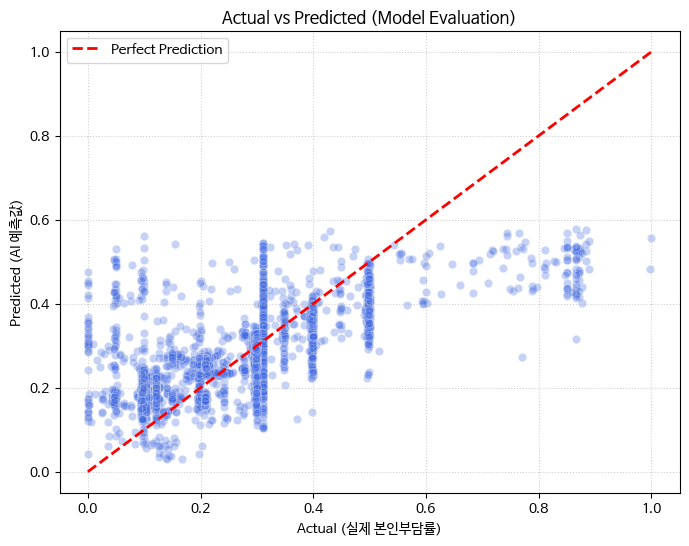

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 샘플링 (1,300만 건을 다 그리면 컴퓨터가 멈출 수 있어요!)
# 5,000개만 무작위로 뽑아서 경향성을 확인합니다.
idx = np.random.choice(len(y_test), size=5000, replace=False)
sample_actual = y_test.iloc[idx]
sample_pred = y_pred[idx]

# 그래프 그리기
plt.figure(figsize=(8, 6))

# seaborn의 scatterplot 사용
# alpha=0.3: 점들이 겹치는 부분을 진하게 보여주어 데이터의 밀도를 확인하게 함
sns.scatterplot(x=sample_actual, y=sample_pred, alpha=0.3, color='royalblue')

# 45도 기준선 그리기 (완벽한 정답선)
# 실제값과 예측값이 똑같다면 점들이 이 선 위에 예쁘게 모여야 합니다.
line_range = [0, 1] # 본인부담률은 0에서 1 사이이므로
plt.plot(line_range, line_range, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 그래프 꾸미기 (이해하기 쉽게 한글/영어 라벨 추가)
plt.xlabel("Actual (실제 본인부담률)")
plt.ylabel("Predicted (AI 예측값)")
plt.title("Actual vs Predicted (Model Evaluation)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## 모델링 - LightGBM

In [25]:
import lightgbm as lgb

# LightGBM 데이터셋을 만들면 속도가 더 빠름
train_set = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
test_set = lgb.Dataset(X_test, label=y_test, categorical_feature=cat_cols)

params = {
    'objective': 'regression',   # 회귀 분석 (수치 예측)
    'metric': 'rmse',            # 평가 지표: 평균 에러(RMSE)를 줄이는 방향으로 공부함
    'learning_rate': 0.05,       # 학습 속도: 너무 빠르면 대충 공부하고, 너무 느리면 오래 걸림
    'num_leaves': 64,            # 나무의 복잡도: 숫자가 클수록 꼼꼼하게 공부하지만 과적합 위험 있음
    'verbose': -1                # 불필요한 로그 메시지 출력 안 함
}

print("LightGBM 모델 학습을 시작합니다...")
model = lgb.train(
    params,
    train_set,
    valid_sets=[test_set],
    num_boost_round=300, # 최대 300번까지 반복 학습
    callbacks=[lgb.early_stopping(stopping_rounds=30)]
)

y_pred = model.predict(X_test)

# 평가 지표 계산
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("-" * 30)
print(f"최종 평가 결과 (LinearRegression)")
print(f"1. 오차 정도(RMSE): {rmse:.4f} (정답과 평균적으로 이만큼 차이남)")
print(f"2. 모델의 설명력(R2): {r2:.4f} (100% 중 약 {r2*100:.1f}%의 정답률)")
print("-" * 30)

LightGBM 모델 학습을 시작합니다...
Training until validation scores don't improve for 30 rounds
Did not meet early stopping. Best iteration is:
[300]	valid_0's rmse: 0.0887165
------------------------------
최종 평가 결과 (LinearRegression)
1. 오차 정도(RMSE): 0.0887 (정답과 평균적으로 이만큼 차이남)
2. 모델의 설명력(R2): 0.5345 (100% 중 약 53.4%의 정답률)
------------------------------


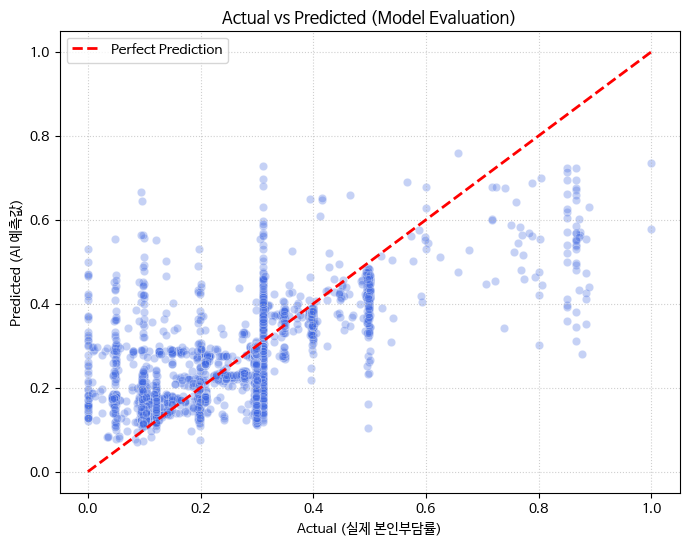

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 샘플링 (1,300만 건을 다 그리면 컴퓨터가 멈출 수 있어요!)
# 5,000개만 무작위로 뽑아서 경향성을 확인합니다.
idx = np.random.choice(len(y_test), size=5000, replace=False)
sample_actual = y_test.iloc[idx]
sample_pred = y_pred[idx]

# 그래프 그리기
plt.figure(figsize=(8, 6))

# seaborn의 scatterplot 사용
# alpha=0.3: 점들이 겹치는 부분을 진하게 보여주어 데이터의 밀도를 확인하게 함
sns.scatterplot(x=sample_actual, y=sample_pred, alpha=0.3, color='royalblue')

# 45도 기준선 그리기 (완벽한 정답선)
# 실제값과 예측값이 똑같다면 점들이 이 선 위에 예쁘게 모여야 합니다.
line_range = [0, 1] # 본인부담률은 0에서 1 사이이므로
plt.plot(line_range, line_range, color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# 그래프 꾸미기 (이해하기 쉽게 한글/영어 라벨 추가)
plt.xlabel("Actual (실제 본인부담률)")
plt.ylabel("Predicted (AI 예측값)")
plt.title("Actual vs Predicted (Model Evaluation)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## 다중분류모델

In [27]:
# 구간 분류용 타겟 생성
bins = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
labels = ['0~10%', '10~30%', '30~50%', '50~70%', '70~100%']

df_sample['본인부담률_class'] = pd.cut(
    df_sample['본인부담률'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)
print(df_sample['본인부담률_class'].value_counts())

본인부담률_class
10~30%     915684
30~50%     266168
0~10%      171411
70~100%     22390
50~70%       7485
Name: count, dtype: int64


In [28]:
X = df_sample[selected_features].copy()
y = df_sample['본인부담률_class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, random_state=42,
    stratify=y
)
print(f"전체 데이터 형태: {df_sample.shape}")
print(f"학습 데이터 형태 (X_train): {X_train.shape}")
print(f"테스트 데이터 형태 (X_test): {X_test.shape}")

전체 데이터 형태: (1383138, 12)
학습 데이터 형태 (X_train): (1106510, 10)
테스트 데이터 형태 (X_test): (276628, 10)


In [29]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("-" * 30)
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 30)
print("상세 평가 보고서:")
print(classification_report(y_test, y_pred))

------------------------------
정확도(Accuracy): 0.7377
------------------------------
상세 평가 보고서:
              precision    recall  f1-score   support

       0~10%       0.36      0.67      0.47     34282
      10~30%       0.92      0.75      0.83    183137
      30~50%       0.80      0.75      0.77     53234
      50~70%       0.15      0.70      0.25      1497
     70~100%       0.49      0.72      0.58      4478

    accuracy                           0.74    276628
   macro avg       0.54      0.72      0.58    276628
weighted avg       0.82      0.74      0.76    276628



In [30]:
from lightgbm import LGBMClassifier

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1, #학습 속도
        max_dapty=7,
        random_state=42,
        n_jobs=-1,
        importance_type='gain'
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("-" * 30)
print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("-" * 30)
print("상세 평가 보고서:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


------------------------------
정확도(Accuracy): 0.8202
------------------------------
상세 평가 보고서:
              precision    recall  f1-score   support

       0~10%       0.58      0.19      0.28     34282
      10~30%       0.84      0.96      0.90    183137
      30~50%       0.82      0.78      0.80     53234
      50~70%       0.37      0.19      0.25      1497
     70~100%       0.54      0.73      0.62      4478

    accuracy                           0.82    276628
   macro avg       0.63      0.57      0.57    276628
weighted avg       0.80      0.82      0.79    276628

